# China Cities


### 5.0 Notebook Setup and Inputs
This notebook prepares city-level aging-rate data and projections for national comparison figures. It reads the filtered China city boundary layer, census age tables, and WorldPop-derived projection inputs, then runs reusable scripts that write processed city panels and figures.


In [1]:
from pathlib import Path

import geopandas as gpd

RAW_DIR = Path("../data/raw")
PROCESSED_DIR = Path("../data/processed")
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

# Load the filtered national city boundary layer shared by the census and projection scripts.
china_city = gpd.read_file(RAW_DIR / "china_city_filtered_297.shp")
china_city.head()


,省,省代码,市,市代码,市类型,省类型,geometry
0,安徽省,340000,安庆市,340800,地级市,省,"POLYGON ((117.04743 31.23795, 117.04959 31.237..."
1,安徽省,340000,蚌埠市,340300,地级市,省,"POLYGON ((117.24217 33.50295, 117.24328 33.502..."
2,安徽省,340000,亳州市,341600,地级市,省,"POLYGON ((115.75364 34.06824, 115.75751 34.067..."
3,安徽省,340000,池州市,341700,地级市,省,"POLYGON ((117.97799 30.82233, 117.97173 30.816..."
4,安徽省,340000,滁州市,341100,地级市,省,"POLYGON ((118.21608 33.14179, 118.21502 33.129..."


## Census Age Tables


### 5.1 Census Age Tables
This section runs the census-processing scripts for 2000, 2010, and 2020 and merges them into a city panel. The merged panel supports observed aging-rate comparisons across selected Chinese cities.


In [3]:
# Parse 2010 census age tables into standardized city-age outputs.
%run ../src/census_2010.py


Detected sheets: ['1', '2', '3', '4', '5', '6', '7', '8', '9', '10', '11', '12', '13', '14', '15', '16', '17', '18', '19', '20', '21', '22', '23', '24', '25', '26', '27', '28', '29', '30', '31', '32', '33', '34', '35', '36', '37', '38', '39', '40', '41', '42', '43', '44', '45', '46', '47', '48', '49', '50', '51', '52', '53', '54', '55', '56', '57', '58', '59', '60', '61', '62', '63', '64', '65', '66', '67', '68', '69', '70', '71', '72', '73', '74', '75', '76', '77', '78', '79', '80', '81', '82', '83', '84', '85', '86', '87', '88', '89', '90', '91', '92', '93', '94', '95', '96', '97', '98', '99', '100', 'CNKI']
Merging: 1 (ages 0-44) + 2 (ages 45+)
Merging: 3 (ages 0-44) + 4 (ages 45+)
Merging: 5 (ages 0-44) + 6 (ages 45+)
Merging: 7 (ages 0-44) + 8 (ages 45+)
Merging: 9 (ages 0-44) + 10 (ages 45+)
Merging: 11 (ages 0-44) + 12 (ages 45+)
Merging: 13 (ages 0-44) + 14 (ages 45+)
Merging: 15 (ages 0-44) + 16 (ages 45+)
Merging: 17 (ages 0-44) + 18 (ages 45+)
Merging: 19 (ages 0-44) + 20 (a

In [4]:
# Parse 2020 census age tables using the same standardized schema.
%run ../src/census_2020.py


Reading data...
------------------------------
2020 census processing complete.
Prefecture-level city count: 683
Saved to: /Users/kkzhu/Documents/Aexercise/Shenzhen/shenzhen_acc/shenzhen_aging/data/processed/pop_census/merged_national_city_age_2020.xlsx


In [5]:
# Parse 2000 census age tables to complete the observed three-census panel.
%run ../src/census_2000.py


Reading 2000 census data...
------------------------------
2000 census processing complete.
Filtered city count: 261
Saved to: /Users/kkzhu/Documents/Aexercise/Shenzhen/shenzhen_acc/shenzhen_aging/data/processed/pop_census/merged_national_city_age_2000.xlsx


In [6]:
# Merge observed census years into a single city-level aging panel.
%run ../src/merge_census_panel.py


Processing 2000: merged_national_city_age_2000.xlsx
Processing 2010: merged_national_city_age_2010.xlsx
Processing 2020: merged_national_city_age_2020.xlsx
------------------------------
Three-period census panel generated.
Total rows: 1596
City count: 719
Output file: /Users/kkzhu/Documents/Aexercise/Shenzhen/shenzhen_acc/shenzhen_aging/data/processed/pop_census/city_census_panel_2000_2010_2020.xlsx


------------------------------
Aging-rate line chart generated.
City count: 9
PNG output: /Users/kkzhu/Documents/Aexercise/Shenzhen/shenzhen_acc/shenzhen_aging/figures/selected_cities_aging_rate_60plus.png
PDF output: /Users/kkzhu/Documents/Aexercise/Shenzhen/shenzhen_acc/shenzhen_aging/figures/selected_cities_aging_rate_60plus.pdf


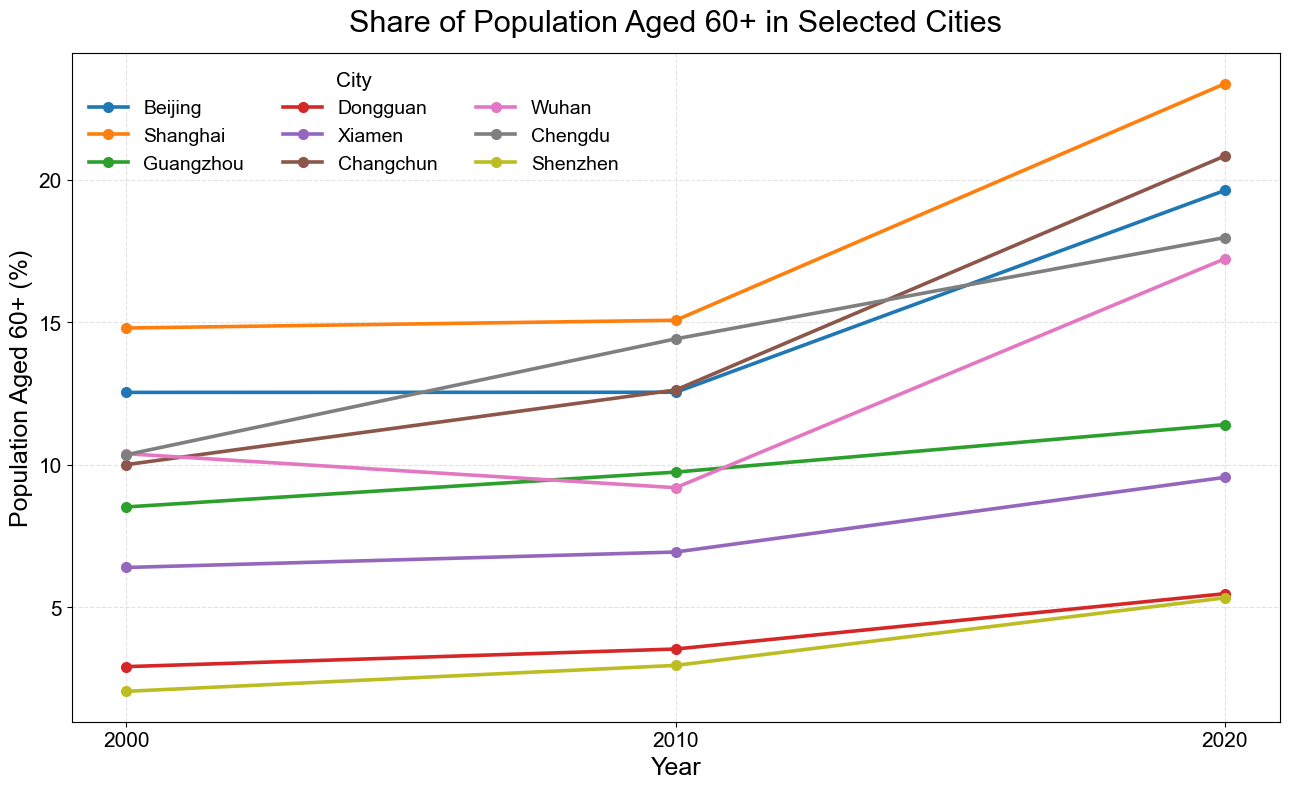

In [7]:
# Save selected-city observed aging-rate plots for figure reuse.
%run ../src/plot_cities_aging.py


## 2020-2035 Aging-Rate Projection


### 5.2 2020-2035 Aging-Rate Projection
This section prepares WorldPop age-structure inputs and projects city aging rates through 2035. It produces the main near-term projection tables and plots used for the city comparison workflow.


In [10]:
# Age structure data for the China region must be downloaded from WorldPop
#  (e.g., chn_f_0_2020_constrained_UNadj.tif).
# https://hub.worldpop.org/geodata/summary?id=16998

# Build 2020 city age structure from downloaded WorldPop age-sex rasters.
%run ../src/city_age_structure_v2.py


Found 36 valid raster files.
Raster CRS: EPSG:4326
Raster nodata: -99999.0
Processing: chn_f_0_2020_constrained_UNadj.tif -> sex=female, age=0
Processing: chn_f_10_2020_constrained_UNadj.tif -> sex=female, age=10-14
Processing: chn_f_15_2020_constrained_UNadj.tif -> sex=female, age=15-19
Processing: chn_f_20_2020_constrained_UNadj.tif -> sex=female, age=20-24
Processing: chn_f_1_2020_constrained_UNadj.tif -> sex=female, age=1-4
Processing: chn_f_25_2020_constrained_UNadj.tif -> sex=female, age=25-29
Processing: chn_f_30_2020_constrained_UNadj.tif -> sex=female, age=30-34
Processing: chn_f_35_2020_constrained_UNadj.tif -> sex=female, age=35-39
Processing: chn_f_40_2020_constrained_UNadj.tif -> sex=female, age=40-44
Processing: chn_f_45_2020_constrained_UNadj.tif -> sex=female, age=45-49
Processing: chn_f_50_2020_constrained_UNadj.tif -> sex=female, age=50-54
Processing: chn_f_55_2020_constrained_UNadj.tif -> sex=female, age=55-59
Processing: chn_f_5_2020_constrained_UNadj.tif -> sex=fem

In [11]:
# Project city age structure from the 2020 baseline to future target years.
%run ../src/project_age_structure.py


------------------------------
2020-2035 city age-structure projection complete.
Total rows: 1184
City count: 296
Output file: /Users/kkzhu/Documents/Aexercise/Shenzhen/shenzhen_acc/shenzhen_aging/data/processed/city_age_projection_2020_2035.xlsx


In [15]:
# Generate the 2020-2035 city aging-rate projection table.
%run ../src/population_projection_v3.py


----------------------------------------
2000-2050 city age-structure panel generated.
Output file: /Users/kkzhu/Documents/Aexercise/Shenzhen/shenzhen_acc/shenzhen_aging/data/processed/city_age_panel_2000_2050_calibrated.xlsx
Total rows: 3372
City count: 719


----------------------------------------
Done.
PNG: /Users/kkzhu/Documents/Aexercise/Shenzhen/shenzhen_acc/shenzhen_aging/figures/selected_cities_aging_rate_2000_2035_final.png
PDF: /Users/kkzhu/Documents/Aexercise/Shenzhen/shenzhen_acc/shenzhen_aging/figures/selected_cities_aging_rate_2000_2035_final.pdf


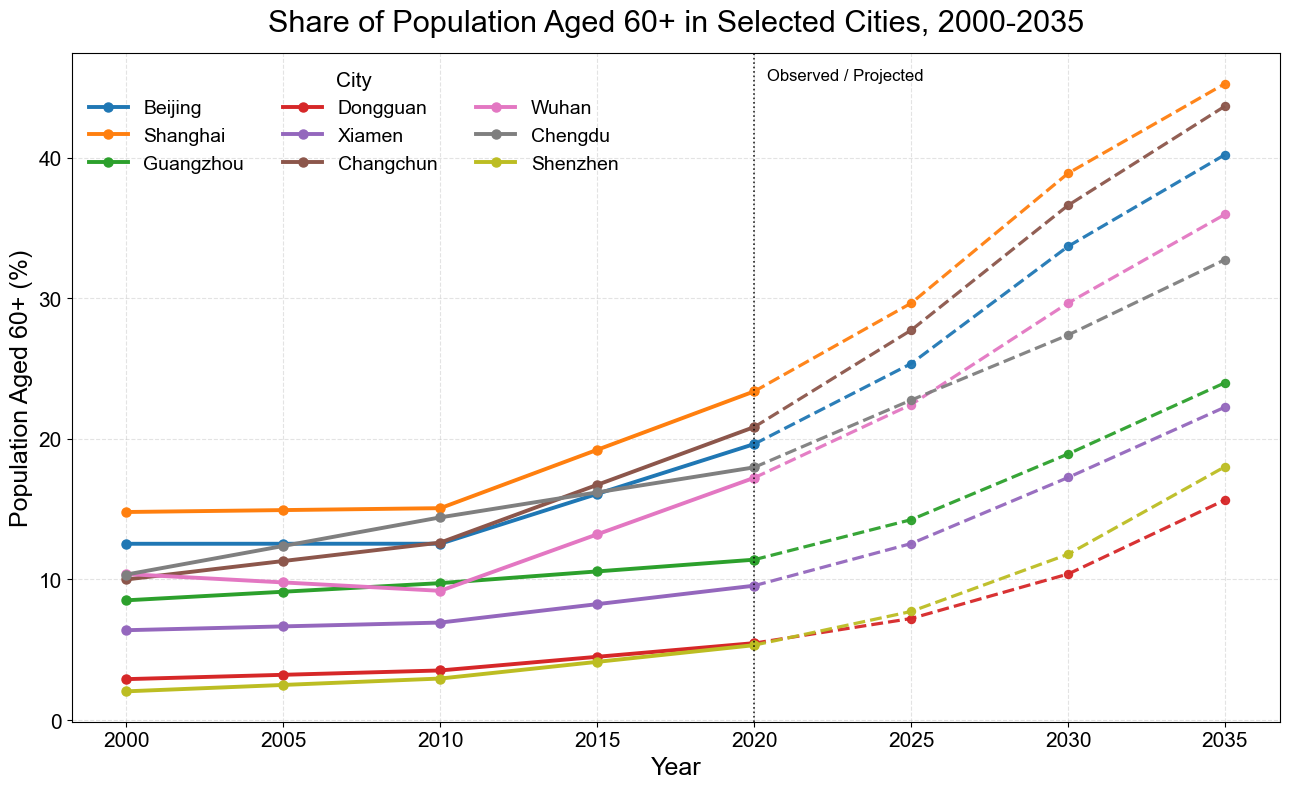

In [17]:
# Save the first 2020-2035 projection figure variant.
%run ../src/plot_projection_v1.py


----------------------------------------
Done.
PNG: /Users/kkzhu/Documents/Aexercise/Shenzhen/shenzhen_acc/shenzhen_aging/figures/selected_cities_aging_rate_2000_2035_final.png
PDF: /Users/kkzhu/Documents/Aexercise/Shenzhen/shenzhen_acc/shenzhen_aging/figures/selected_cities_aging_rate_2000_2035_final.pdf


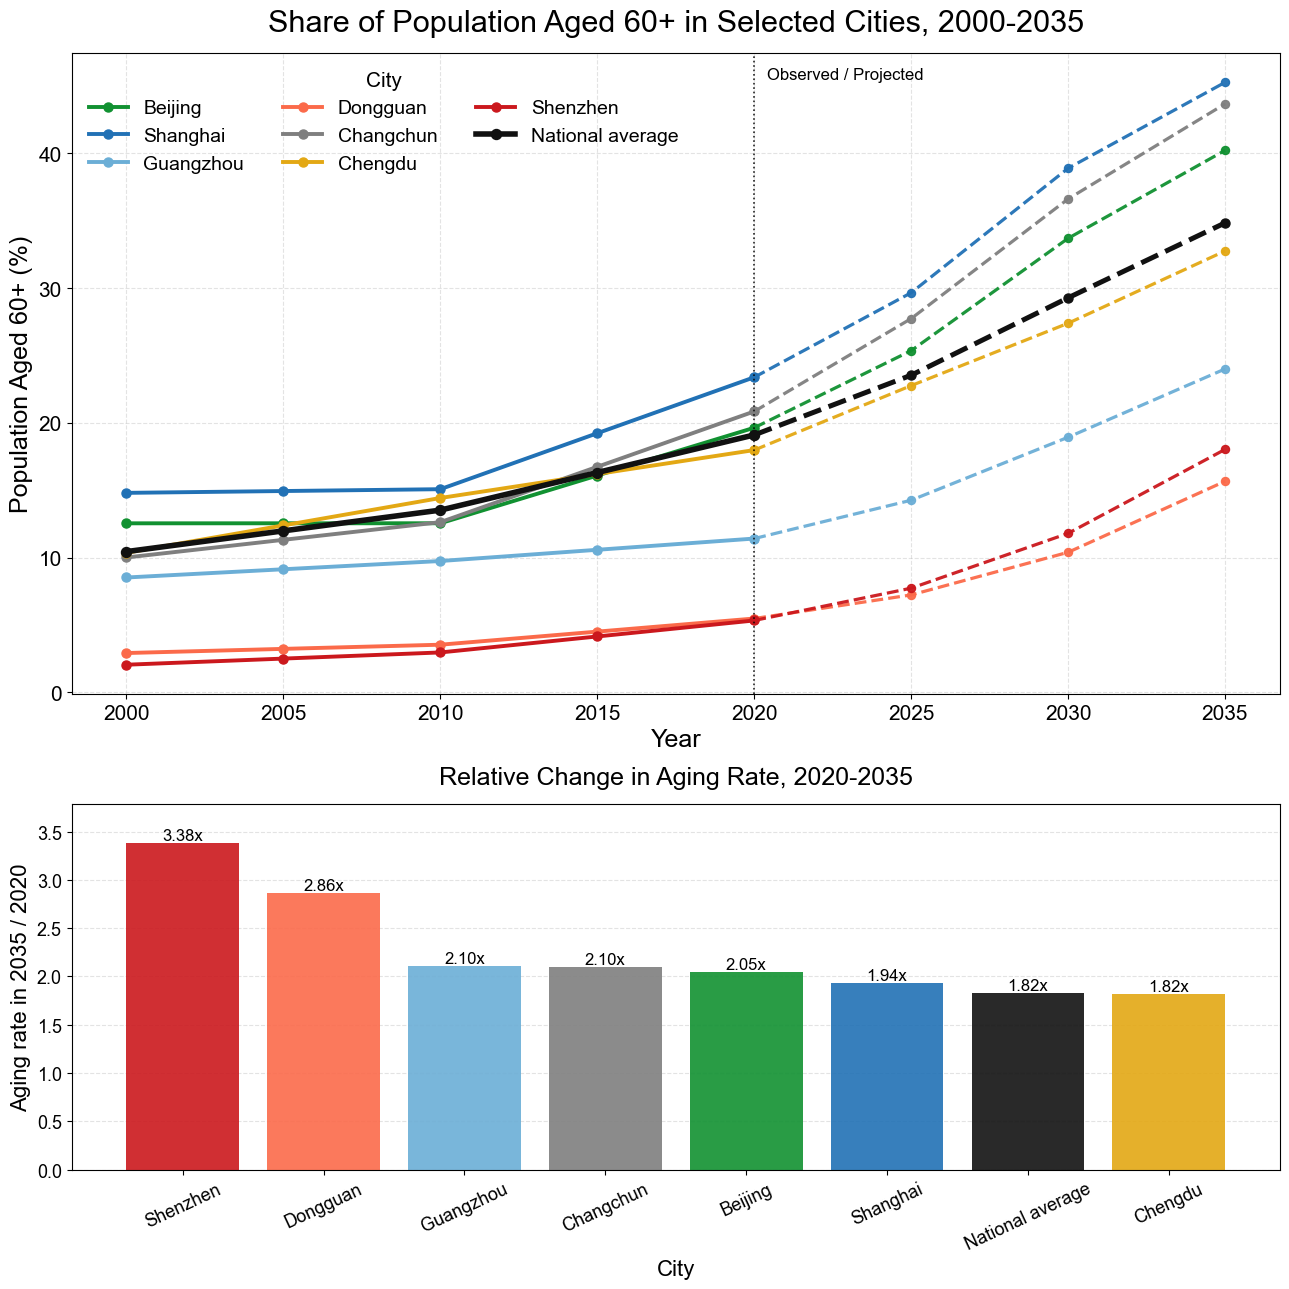

In [18]:
# Save the final 2020-2035 selected-city projection figure.
%run ../src/plot_projection_v3.py


## 2020-2050 Aging-Rate Projection


### 5.3 2020-2050 Aging-Rate Projection
This section extends the city projection horizon to 2050 using the long-range projection script. The outputs provide longer-term sensitivity figures while preserving the same city and age-structure workflow.


In [19]:
# Generate the extended 2020-2050 city aging-rate projection table.
%run ../src/population_projection_v4.py


2020-2050 city age-structure projection complete.
Output file: /Users/kkzhu/Documents/Aexercise/Shenzhen/shenzhen_acc/shenzhen_aging/data/processed/city_age_projection_2020_2050.xlsx


In [20]:
# Generate the 2020-2035 city aging-rate projection table.
%run ../src/population_projection_v3.py


----------------------------------------
2000-2050 city age-structure panel generated.
Output file: /Users/kkzhu/Documents/Aexercise/Shenzhen/shenzhen_acc/shenzhen_aging/data/processed/city_age_panel_2000_2050_calibrated.xlsx
Total rows: 3372
City count: 719


PNG: /Users/kkzhu/Documents/Aexercise/Shenzhen/shenzhen_acc/shenzhen_aging/figures/selected_cities_aging_rate_2000_2050_final.png
PDF: /Users/kkzhu/Documents/Aexercise/Shenzhen/shenzhen_acc/shenzhen_aging/figures/selected_cities_aging_rate_2000_2050_final.pdf


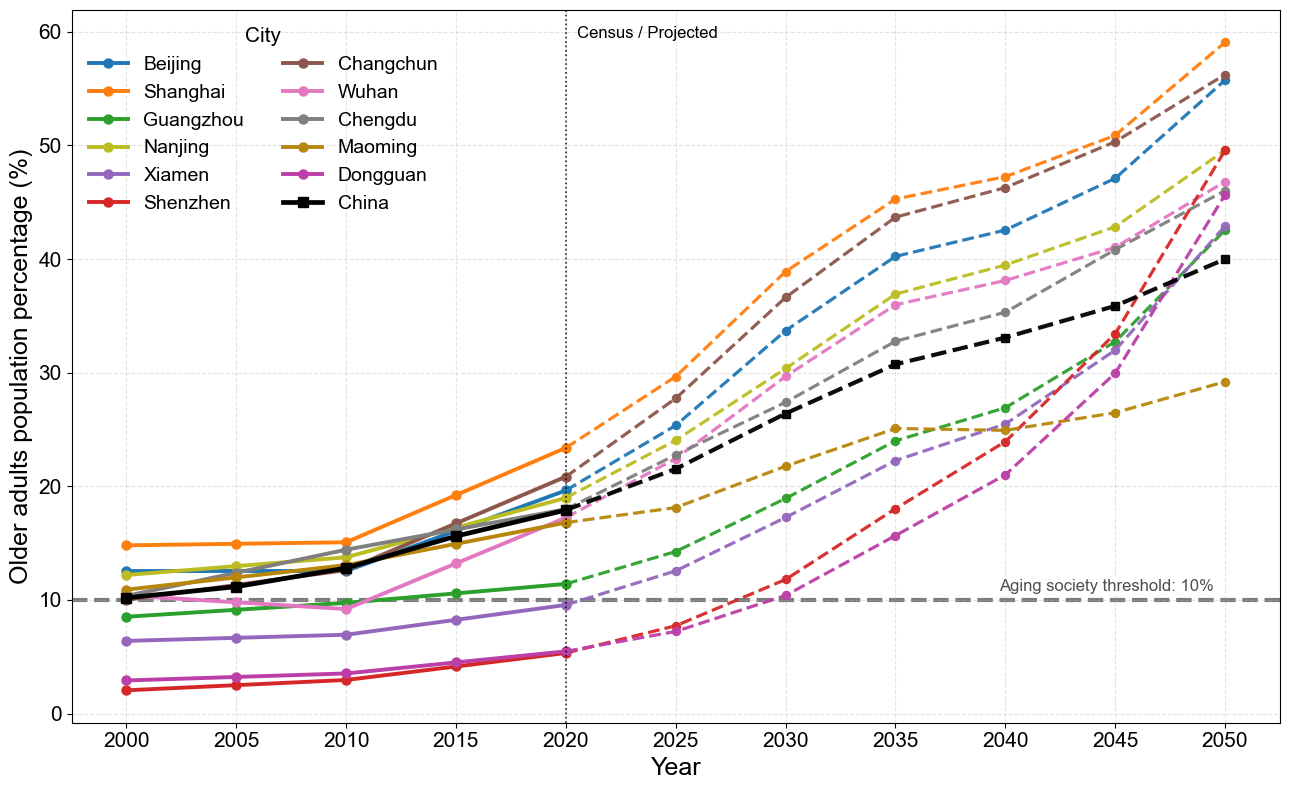

In [ ]:
# Save the 2020-2050 selected-city projection figure.
%run ../src/plot_projection_v2.py